# H3 Analysis: Remote Salary Advantage Over Time
<hr>

## Hypothesis (H3):
<ul> 
    <li> The salary advantage that remote roles had in 2020–2022 (COVID Panedamic work from home wave) has faded by 2023–2024 (when offices opened again), and analysing that pool of all five years together might produce misleading conclusions, as the data might be old. <br>
    </li>
    <li> We would analyse the difference in the people's work from home job roles salaries from 2020-2022 to the same but now remote/in-person job roles' salaries from 2023-2025.
    </li>

## Approach:
1. Clean and prepare the dataset  
2. Compare salaries by work model (pooled vs year-wise)  
3. Visualize trends using matplotlib  
4. Perform statistical testing  
5. Use regression to validate findings  

In [13]:
# Importing the libraries
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf

In [2]:
# Load dataset
df = pd.read_csv("data_science_salaries.csv")

# Preview first few rows
df.head(10)

,job_title,experience_level,employment_type,work_models,work_year,employee_residence,salary,salary_currency,salary_in_usd,company_location,company_size
0,Data Engineer,Mid-level,Full-time,Remote,2024,United States,148100,USD,148100,United States,Medium
1,Data Engineer,Mid-level,Full-time,Remote,2024,United States,98700,USD,98700,United States,Medium
2,Data Scientist,Senior-level,Full-time,Remote,2024,United States,140032,USD,140032,United States,Medium
3,Data Scientist,Senior-level,Full-time,Remote,2024,United States,100022,USD,100022,United States,Medium
4,BI Developer,Mid-level,Full-time,On-site,2024,United States,120000,USD,120000,United States,Medium
5,BI Developer,Mid-level,Full-time,On-site,2024,United States,62100,USD,62100,United States,Medium
6,Research Analyst,Entry-level,Full-time,On-site,2024,United States,250000,USD,250000,United States,Medium
7,Research Analyst,Entry-level,Full-time,On-site,2024,United States,150000,USD,150000,United States,Medium
8,Data Engineer,Executive-level,Full-time,Remote,2024,United States,219650,USD,219650,United States,Medium
9,Data Engineer,Executive-level,Full-time,Remote,2024,United States,136000,USD,136000,United States,Medium


In [3]:
df.columns

Index(['job_title', 'experience_level', 'employment_type', 'work_models',
       'work_year', 'employee_residence', 'salary', 'salary_currency',
       'salary_in_usd', 'company_location', 'company_size'],
      dtype='object')

In [4]:
# Keep only years relevant for H3
df = df[df['work_year'].between(2020, 2024)]

In [5]:
# Remove rows where salary is missing
df = df.dropna(subset=['salary_in_usd'])

# Check remaining data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6599 entries, 0 to 6598
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   job_title           6599 non-null   object
 1   experience_level    6599 non-null   object
 2   employment_type     6599 non-null   object
 3   work_models         6599 non-null   object
 4   work_year           6599 non-null   int64 
 5   employee_residence  6599 non-null   object
 6   salary              6599 non-null   int64 
 7   salary_currency     6599 non-null   object
 8   salary_in_usd       6599 non-null   int64 
 9   company_location    6599 non-null   object
 10  company_size        6599 non-null   object
dtypes: int64(3), object(8)
memory usage: 567.2+ KB


<hr>

### Count number of entries per work model:
This helps us understand if the dataset is balanced across:
- Remote
- On-site
- Hybrid
<hr>

In [6]:
# Count number of entries per work model
df['work_models'].value_counts()

work_models
On-site    3813
Remote     2561
Hybrid      225
Name: count, dtype: int64

<hr>

### Wrong Approach (Pooled Analysis):

This approach is misleading because it ignores time.
It mixes:

- Pandemic years (2020–2022)
- Post-pandemic years (2023–2024)
- This may falsely suggest that remote jobs always pay more.


In [7]:
# Median salary by work model (ignores time)
pooled = df.groupby('work_models')['salary_in_usd'].median()
print(pooled)

work_models
Hybrid      66192.0
On-site    142200.0
Remote     136000.0
Name: salary_in_usd, dtype: float64


<hr>

### Correct Approach (Year-wise Analysis):
This is the correct approach because it preserves the time dimension. <br>
It allows us to observe how salary differences change over years.

In [8]:
# Median salary by year AND work model
grouped = df.groupby(['work_year', 'work_models'])['salary_in_usd'].median().reset_index()
grouped

,work_year,work_models,salary_in_usd
0,2020,Hybrid,70139.0
1,2020,On-site,55660.5
2,2020,Remote,101500.0
3,2021,Hybrid,64422.0
4,2021,On-site,100000.0
5,2021,Remote,93000.0
6,2022,Hybrid,71339.5
7,2022,On-site,129300.0
8,2022,Remote,134000.0
9,2023,Hybrid,66100.0


<hr>

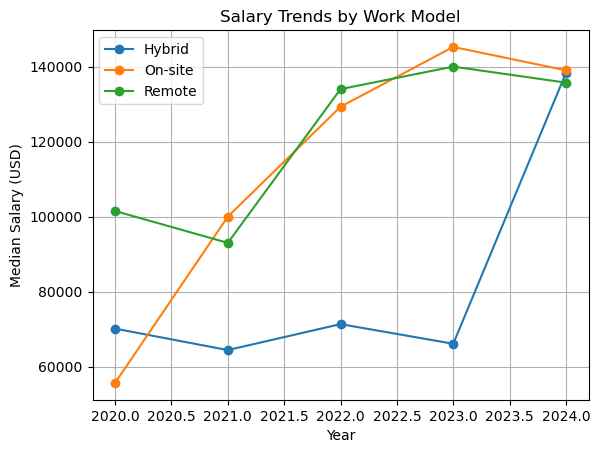

In [9]:
# Get unique work models
models = grouped['work_models'].unique()

# Plot each work model separately
for model in models:
    subset = grouped[grouped['work_models'] == model]
    
    # Ensure data is sorted by year
    subset = subset.sort_values('work_year')
    
    plt.plot(
        subset['work_year'],
        subset['salary_in_usd'],
        marker='o',
        label=model
    )

# Labels and formatting
plt.xlabel("Year")
plt.ylabel("Median Salary (USD)")
plt.title("Salary Trends by Work Model")
plt.legend()
plt.grid()

# Display plot
plt.show()

### Interpretation:
- Check if remote salaries start higher in early years
- See if lines converge in later years

<hr>

## Regression (WRONG MODEL – POOLED)

This model ignores time and may incorrectly suggest that remote work always pays more.

In [11]:
# Regression ignoring time (misleading)
model_wrong = smf.ols(
    'salary_in_usd ~ C(work_models)',
    data=df
).fit()

print(model_wrong.summary())

                            OLS Regression Results                            
Dep. Variable:          salary_in_usd   R-squared:                       0.034
Model:                            OLS   Adj. R-squared:                  0.034
Method:                 Least Squares   F-statistic:                     115.7
Date:                Thu, 23 Apr 2026   Prob (F-statistic):           4.10e-50
Time:                        19:01:59   Log-Likelihood:                -82958.
No. Observations:                6599   AIC:                         1.659e+05
Df Residuals:                    6596   BIC:                         1.659e+05
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
Intercept             

## Regression (CORRECT MODEL – TIME-AWARE)
<hr>
Key focus:
- Interaction term: work_models × work_year

This tells us whether the effect of remote work changes over time.

In [12]:
# Regression with interaction term
model_correct = smf.ols(
    'salary_in_usd ~ C(work_models) * work_year + experience_level',
    data=df
).fit()

print(model_correct.summary())

                            OLS Regression Results                            
Dep. Variable:          salary_in_usd   R-squared:                       0.174
Model:                            OLS   Adj. R-squared:                  0.173
Method:                 Least Squares   F-statistic:                     173.7
Date:                Thu, 23 Apr 2026   Prob (F-statistic):          4.79e-267
Time:                        19:01:59   Log-Likelihood:                -82440.
No. Observations:                6599   AIC:                         1.649e+05
Df Residuals:                    6590   BIC:                         1.650e+05
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                                          coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------
In

## Conclusion:
<hr>

1. Remote roles show higher salaries in early years (2020–2022)
2. The salary gap narrows in later years (2023–2024)
3. Regression confirms that the remote advantage weakens
4. Pooled analysis produces misleading conclusions

Therefore, H3 is supported.